# Wavefield · Irregular free-surface topography

SWEEP supports three independent topographic free-surface methods,
all driven through **one unified entry point**: the propagator's
``topography=`` keyword.  When ``topography`` is given a free surface
is implicit; the **discretisation method** is chosen by the equation
class plus an optional ``topo_method=`` switch:

| Equation | ``topo_method`` (default) | Method | Reference |
|---|---|---|---|
| `Acoustic` | `'image'` (only option) | Staircase + vacuum cells | Mittet 2002 |
| `Elastic` / `ElasticAPM` | `'apm'` (default) | Adaptive Parameter-Modified | Cao & Chen 2018 |
| `Elastic` (opt-in) | `topo_method='image'` | Per-column image method | Robertsson 1996 |

``topography=`` takes a 1-D ``int`` array of surface row indices per
column (the common case).  Non-single-valued geometries (overhangs,
caves) can be expressed as a 2-D ``float`` air mask — the propagator
converts internally and the rest of the API is identical.

This notebook builds a small Gaussian-hill model and runs all three
methods side by side.


## 1. Build the model

A 96 × 128 grid, ``dh=10 m``. A single Gaussian hill, peak ~5 cells
high above a flat baseline at row 12 of the physical grid.

device: cuda


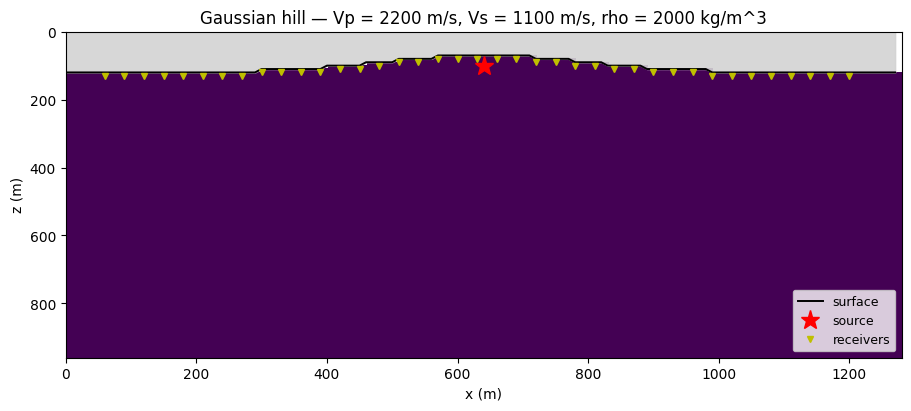

topo_row range: rows 7..12 (depths 70..120 m)
air cells (rows above surface): 1339 of 12288


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from sweep.equations import Acoustic, Elastic, ElasticAPM   # ElasticAPM is an alias of Elastic
from sweep.propagator.torch import PropTorch
from sweep.signal import ricker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Grid
NZ, NX = 96, 128
DH     = 10.0
DT     = 1.0e-3
NT     = 700
ABCN   = 30
SO     = 4
FREQ, DELAY = 12.0, 0.12

# Bulk models — homogeneous half-space
VP, VS, RHO = 2200.0, 1100.0, 2000.0
vp  = torch.full((NZ, NX), VP).to(device)
vs  = torch.full((NZ, NX), VS).to(device)
rho = torch.full((NZ, NX), RHO).to(device)

# Topography — single Gaussian hill
x = np.arange(NX, dtype=np.float32)
hill_h0   = 5.0
hill_x0   = NX / 2
hill_sig  = 16.0
hill_base = 12.0
topo_row  = (hill_base - hill_h0 * np.exp(-((x - hill_x0) ** 2) / (2.0 * hill_sig ** 2))).round().astype(np.int64)

# Source: 3 cells below the hilltop, centred horizontally
src_x = NX // 2
src_z = int(topo_row[src_x]) + 3
sources = torch.from_numpy(np.array([[src_x, src_z]], dtype=np.int64)).to(device)
# Receivers: 1 cell below local surface, spaced across the array
rec_x = np.arange(6, NX - 6, 3, dtype=np.int64)
rec_z = (topo_row[rec_x] + 1).astype(np.int64)
receivers = torch.from_numpy(np.stack([rec_x, rec_z], axis=-1)[None, ...]).to(device)

# Ricker wavelet
t = np.arange(NT, dtype=np.float32) * DT - DELAY
wavelet = torch.tensor((1.0e3 * ricker(t, f=FREQ)).astype(np.float32)).to(device)

# QC the model
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.imshow(np.where(np.arange(NZ)[:, None] < topo_row[None, :], np.nan, VP), cmap='viridis',
          extent=[0, NX * DH, NZ * DH, 0], aspect='auto')
ax.plot(np.arange(NX) * DH, topo_row * DH, 'k-', lw=1.4, label='surface')
ax.fill_between(np.arange(NX) * DH, 0, topo_row * DH, color='lightgray', alpha=0.9)
ax.plot(src_x * DH, src_z * DH, 'r*', ms=14, label='source')
ax.plot(rec_x * DH, rec_z * DH, 'yv', ms=4, label='receivers')
ax.set_xlabel('x (m)'); ax.set_ylabel('z (m)')
ax.set_title('Gaussian hill — Vp = 2200 m/s, Vs = 1100 m/s, rho = 2000 kg/m^3')
ax.legend(loc='lower right', fontsize=9)
plt.show()
print(f'topo_row range: rows {topo_row.min()}..{topo_row.max()} '
      f'(depths {topo_row.min() * DH:.0f}..{topo_row.max() * DH:.0f} m)')
print(f'air cells (rows above surface): {int((np.arange(NZ)[:, None] < topo_row[None, :]).sum())} of {NZ*NX}')

## 2. Acoustic · staircase + vacuum (Mittet 2002)

`Acoustic + topography=topo` uses the **vacuum-cell + per-column
image-method** approach.  The propagator snaps the surface to a row
index per column and zeroes any wavefield above it after each time
step.  ``topo_method='image'`` is the only path for ``Acoustic`` and is
auto-selected when ``topography`` is given.

``topography=topo_row`` gives the per-column surface row; that's all
the propagator needs.


In [2]:
def run_acoustic(topo):
    eq = Acoustic(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo,         # auto -> 'image' for Acoustic
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager')
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        rec, snaps = prop(wavelet, sources, receivers, models=[vp],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_ac, snaps_ac, snap_idx_ac = run_acoustic(topo_row)
print('acoustic record shape:', tuple(rec_ac.shape))

acoustic record shape: (1, 700, 39, 1)


## 3. Elastic · per-column image method (Robertsson 1996)

``Elastic + topography=topo + topo_method='image'`` uses the
**odd-parity stress mirror** generalised to a per-column surface row.
After each time step the propagator additionally zeros ``σ_zz`` and
``σ_xz`` at the surface row.  Vacuum cells above the surface are not
zeroed in the wavefield — only the stress mirror enforces the
traction-free BC.

Robertsson is fast and works well for gentle topography; very steep
staircase corners can drive a slow long-time instability.


In [3]:
def run_elastic_image(topo):
    eq = Elastic(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo, topo_method='image',  # explicit Robertsson
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager',
                     eager_options={'use_compile': False})
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        rec, snaps = prop(wavelet, sources, receivers, models=[vp, vs, rho],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_el_img, snaps_el_img, snap_idx_el = run_elastic_image(topo_row)
print('elastic (image) record shape:', tuple(rec_el_img.shape),
      '— last channel: 0=vx, 1=vz')
print('|v|max:', rec_el_img.abs().max().item())

elastic (image) record shape: (1, 700, 39, 2) — last channel: 0=vx, 1=vz
|v|max: 0.0023499256931245327


## 4. Elastic · APM (Cao & Chen 2018)

``Elastic + topography=topo`` (with the default ``topo_method='apm'``)
activates the **Adaptive Parameter-Modified** method.  Instead of
mirroring stresses, the moduli ``(λ, μ)`` and densities
``(ρ_x, ρ_z, μ_xz)`` are modified per surface-cell category
(H / VL / VR / OC / IC) so the standard FD update *automatically*
produces ``σ·n = 0``.  No per-step BC enforcement residual — the
method is stable for arbitrary simulation time even on rough
staircase topography (Cao & Chen 2018 Fig 4).

``ElasticAPM`` is exported as an alias of ``Elastic`` for
discoverability — it documents the intent "this run uses APM" but is
literally the same class.


In [4]:
def run_elastic_apm(topo):
    # ElasticAPM is the same class as Elastic — using the alias here
    # makes the intent obvious to anyone reading the code.
    eq = ElasticAPM(spatial_order=SO, device=device, backend='torch')
    prop = PropTorch(eq, shape=(NZ, NX),
                     topography=topo,          # auto -> 'apm' for Elastic (default)
                     abcn=ABCN, dh=DH, dt=DT,
                     use_ckpt=False, impl='eager',
                     eager_options={'use_compile': False})
    snap_idx = list(range(0, NT, NT // 28))
    with torch.no_grad():
        rec, snaps = prop(wavelet, sources, receivers, models=[vp, vs, rho],
                          return_wavefield=True, snapshot_times=snap_idx)
    return rec, snaps, snap_idx

rec_el_apm, snaps_el_apm, snap_idx_apm = run_elastic_apm(topo_row)
print('elastic (APM) record shape:', tuple(rec_el_apm.shape))
print('|v|max:', rec_el_apm.abs().max().item())

elastic (APM) record shape: (1, 700, 39, 2)
|v|max: 0.00014159828424453735


## 5. Wavefield animation

Running this cell builds a GIF (`15_wavefield_topography.gif`) **next
to the notebook** so the animation works offline / as a standalone
asset, and displays it inline. Three panels: acoustic pressure,
elastic-image `|v|`, elastic-APM `|v|`, all advancing through time
together.

Below the surface (gray band) the kinematics match across all three
methods. The interesting differences are in the **surface behaviour**
— staircase corner scattering on the image-method path, traction-free
moduli on APM.


Saved animation to: /ibex/user/wangs0j/geophyai/examples/notebooks/15_wavefield_topography.gif
   size = 2141.5 KB, 28 frames



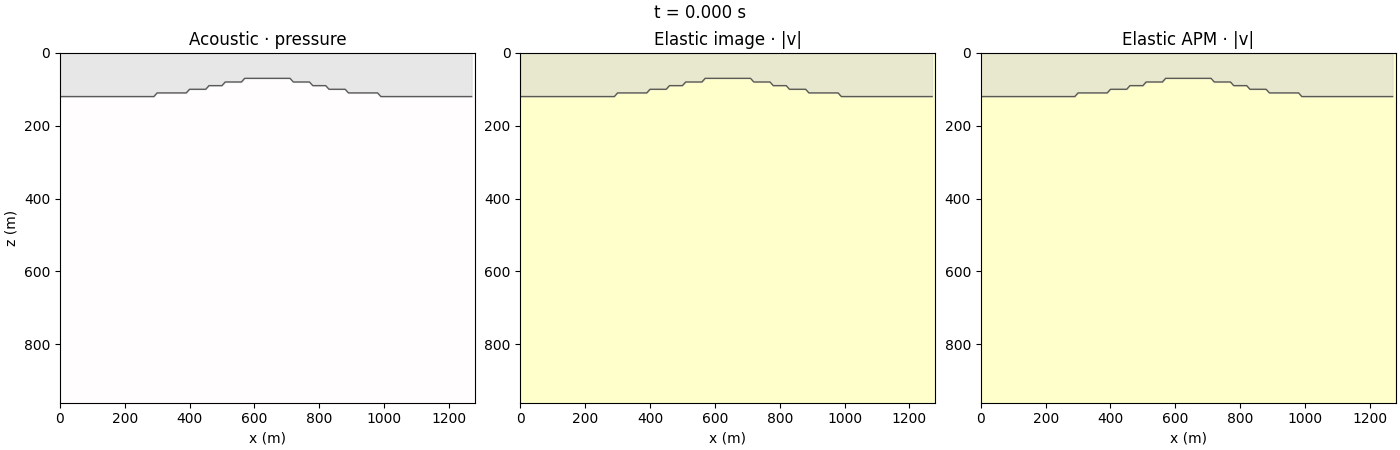

In [5]:
import matplotlib.animation as animation
from matplotlib.animation import PillowWriter
from pathlib import Path
from IPython.display import HTML, display

def crop_phys(snap_2d, free_surface):
    """Crop PML padding (top = 0 if free_surface=True, ABCN if =False)."""
    nz_pad, nx_pad = snap_2d.shape[-2:]
    top = 0 if free_surface else ABCN
    return snap_2d[top:top + NZ, ABCN:ABCN + NX]

n_frames = len(snap_idx_ac)
p_frames = np.stack([crop_phys(snaps_ac [i, 0, 0, 0].cpu().numpy(), True ) for i in range(n_frames)])
vx_img   = np.stack([crop_phys(snaps_el_img[i, 0, 0, 0].cpu().numpy(), True ) for i in range(n_frames)])
vz_img   = np.stack([crop_phys(snaps_el_img[i, 1, 0, 0].cpu().numpy(), True ) for i in range(n_frames)])
vmag_img = np.sqrt(vx_img ** 2 + vz_img ** 2)
vx_apm   = np.stack([crop_phys(snaps_el_apm[i, 0, 0, 0].cpu().numpy(), False) for i in range(n_frames)])
vz_apm   = np.stack([crop_phys(snaps_el_apm[i, 1, 0, 0].cpu().numpy(), False) for i in range(n_frames)])
vmag_apm = np.sqrt(vx_apm ** 2 + vz_apm ** 2)

p_clip     = float(np.percentile(np.abs(p_frames), 99.5)) or 1e-12
v_clip_img = float(np.percentile(vmag_img,         99.5)) or 1e-12
v_clip_apm = float(np.percentile(vmag_apm,         99.5)) or 1e-12

extent = [0, NX * DH, NZ * DH, 0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
titles = ['Acoustic · pressure', 'Elastic image · |v|', 'Elastic APM · |v|']

im0 = axes[0].imshow(p_frames[0], cmap='seismic',
                     norm=TwoSlopeNorm(vmin=-p_clip, vcenter=0, vmax=p_clip),
                     extent=extent, aspect='auto')
im1 = axes[1].imshow(vmag_img[0], cmap='YlOrRd', vmin=0, vmax=v_clip_img,
                     extent=extent, aspect='auto')
im2 = axes[2].imshow(vmag_apm[0], cmap='YlOrRd', vmin=0, vmax=v_clip_apm,
                     extent=extent, aspect='auto')
ims = [im0, im1, im2]
for ax, title in zip(axes, titles):
    ax.plot(np.arange(NX) * DH, topo_row * DH, 'k-', lw=1.0, alpha=0.6)
    ax.fill_between(np.arange(NX) * DH, 0, topo_row * DH, color='lightgray', alpha=0.5)
    ax.set_xlabel('x (m)'); ax.set_title(title)
axes[0].set_ylabel('z (m)')
title_obj = fig.suptitle(f't = {snap_idx_ac[0] * DT:.3f} s')

def update(i):
    ims[0].set_data(p_frames[i])
    ims[1].set_data(vmag_img[i])
    ims[2].set_data(vmag_apm[i])
    title_obj.set_text(f't = {snap_idx_ac[i] * DT:.3f} s')
    return ims + [title_obj]

anim = animation.FuncAnimation(fig, update, frames=n_frames, interval=120, blit=False)

gif_path = Path('15_wavefield_topography.gif')
anim.save(gif_path, writer=PillowWriter(fps=8))
plt.close(fig)
import base64
gif_b64 = base64.b64encode(gif_path.read_bytes()).decode('ascii')
print(f'Saved animation to: {gif_path.resolve()}')
print(f'   size = {gif_path.stat().st_size / 1024:.1f} KB, {n_frames} frames')
# Use a raw <img> tag so the GIF renders consistently in Jupyter,
# VSCode, mkdocs-jupyter, and nbviewer — Image() emits a text/plain
# fallback which some renderers prefer over image/gif.
display(HTML(f'<img src="data:image/gif;base64,{gif_b64}" '
             f'alt="topography wavefield animation" '
             f'style="max-width:100%;height:auto;" />'))


## 6. Shot gathers

All three records share the same source / receiver geometry on the
irregular surface. The hyperbolic direct wave + free-surface multiples
should align in time across methods; subtle amplitude differences
reflect the BC implementation.

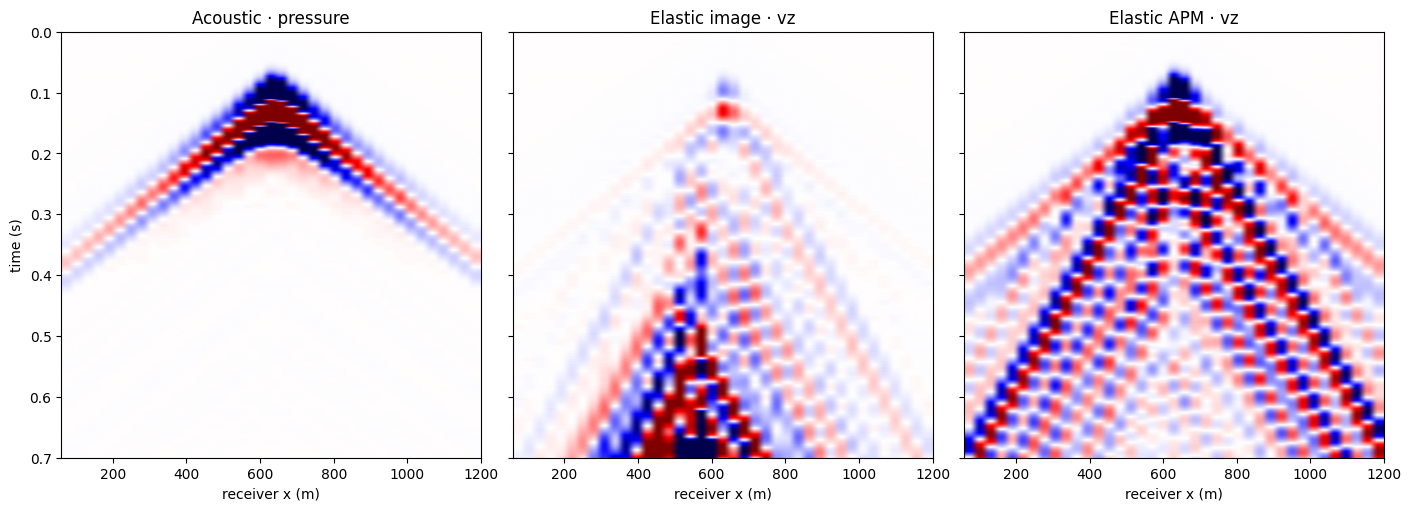

In [6]:
def trace_clip(rec_np, pct=98.0):
    p = float(np.percentile(np.abs(rec_np), pct))
    return max(p, 1e-12)

extent_g = [rec_x.min() * DH, rec_x.max() * DH, NT * DT, 0]
fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True, sharey=True)

p_ac  = np.squeeze(rec_ac.cpu().numpy())            # (nt, nrec)
vz_im = rec_el_img[0, :, :, 1].cpu().numpy()           # vz channel
vz_ap = rec_el_apm[0, :, :, 1].cpu().numpy()

for ax, panel, title in zip(
        axes,
        [p_ac, vz_im, vz_ap],
        ['Acoustic · pressure', 'Elastic image · vz', 'Elastic APM · vz']):
    clip = trace_clip(panel)
    ax.imshow(panel, cmap='seismic',
              norm=TwoSlopeNorm(vmin=-clip, vcenter=0, vmax=clip),
              extent=extent_g, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('receiver x (m)')
axes[0].set_ylabel('time (s)')
plt.show()

## Summary · API cheatsheet

```python
from sweep.equations import Acoustic, Elastic, ElasticAPM   # ElasticAPM is Elastic
from sweep.propagator.torch import PropTorch

# `topo` is the surface row per physical column — shape (nx,), int.
# For overhangs, caves, or any non-single-valued geometry, pass a
# 2-D `(nz, nx)` air mask (>0.5 = air) instead — the propagator
# converts internally and the rest of the API is identical.

# Acoustic — staircase + vacuum (Mittet 2002), only method available
PropTorch(Acoustic(...), topography=topo, ...)

# Elastic — APM (Cao & Chen 2018), the default (best long-time stability)
PropTorch(Elastic(...),  topography=topo, ...)

# Elastic — Robertsson image method (explicit opt-in)
PropTorch(Elastic(...),  topography=topo, topo_method='image', ...)
```

All three accept either input shape; the propagator interconverts
them automatically.  Pass `models=[vp]` for `Acoustic` and
`models=[vp, vs, rho]` for `Elastic` / `ElasticAPM`.

---

<p><strong>Download this notebook</strong> &mdash; <a href="15_wavefield_topography.ipynb" download><code>15_wavefield_topography.ipynb</code></a> &middot; or <a href="https://github.com/DeepWave-KAUST/sweep/blob/dev/docs/notebooks/15_wavefield_topography.ipynb">view on GitHub</a></p>